In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# ------------------------------
# Configuration
# ------------------------------
seilora_ranks = [1, 4, 16, 64, 256, 1024, 2048]

caqtl_datasets = [
    "caqtls_afr_lcl",
    "caqtls_eu_lcl",
    "dsqtls_yoruba_lcl",
    "caqtls_eu_microglia",
    "caqtls_eu_smc",
    "bsqtls_eu_spi1"
]

# ------------------------------
# File mappings
# ------------------------------
chrombpnet_files = {
    "caqtls_afr_lcl": "../data/caqtls.african.lcls.benchmarking.all.tsv",
    "caqtls_eu_lcl": "../data/caqtls.eu.lcls.benchmarking.all.tsv",
    "dsqtls_yoruba_lcl": "../data/dsqtls.yoruba.lcls.benchmarking.all.tsv",
    "caqtls_eu_microglia": "../data/caqtls.microglia.benchmarking.all.tsv",
    "caqtls_eu_smc": "../data/caqtls.smc.benchmarking.all.tsv",
    "bsqtls_eu_spi1": "../data/bqtls.pu1.lcls.benchmarking.all.tsv",
}

enformer_files = {
    "caqtls_afr_lcl": "../data/caqtls.african.lcls.benchmarking.all.tsv",
    "caqtls_eu_lcl": "../data/caqtls.eu.lcls.benchmarking.all.tsv",
    "dsqtls_yoruba_lcl": "../data/dsqtls.yoruba.lcls.benchmarking.all.tsv",
    "caqtls_eu_microglia": "scores/caqtls_eu_microglia_enformer_rankfull.tsv.gz",
    "caqtls_eu_smc": "scores/caqtls_eu_smc_enformer_rankfull.tsv.gz",
    "bsqtls_eu_spi1": "scores/bsqtls_eu_spi1_enformer_rankfull.tsv.gz",
}

# Explicit Sei file mapping (NOT automated)
sei_files = {
    "caqtls_afr_lcl": "scores/caqtls_afr_lcl_seilora_rankfull.tsv.gz",
    "caqtls_eu_lcl": "scores/caqtls_eu_lcl_seilora_rankfull.tsv.gz",
    "dsqtls_yoruba_lcl": "scores/dsqtls_yoruba_lcl_seilora_rankfull.tsv",
    "caqtls_eu_microglia": "scores/caqtls_eu_microglia_seilora_rankfull.tsv.gz",
    "caqtls_eu_smc": "scores/caqtls_eu_smc_seilora_rankfull.tsv.gz",
    "bsqtls_eu_spi1": "scores/bsqtls_eu_spi1_seilora_rankfull.tsv.gz",
}

# ------------------------------
# Initialize dictionary
# ------------------------------
models = {}

# AlphaGenome (numeric results)
models["alphagenome"] = {
    "caqtls_afr_lcl": [0.56, 0.74],
    "caqtls_eu_lcl": [0.36, 0.59],
    "dsqtls_yoruba_lcl": [0.63, 0.83],
    "caqtls_eu_microglia": [0.64],
    "caqtls_eu_smc": [0.70],
    "bsqtls_eu_spi1": [0.55],
}

# Borzoi (numeric placeholders)
models["borzoi"] = {
    "caqtls_afr_lcl": [0.462369, 0.648517],
    "caqtls_eu_lcl": [0.311657, 0.510695],
    "dsqtls_yoruba_lcl": [0.60562, 0.792241],
    "caqtls_eu_microglia": [0.615864],
    "caqtls_eu_smc": [0.63039],
    "bsqtls_eu_spi1": [0.534904],
}

# Enformer and ChromBPNet (loop okay)

models["chrombpnet"] = {
    dataset: filepath
    for dataset, filepath in chrombpnet_files.items()
}
models["enformer"] = {
    dataset: filepath
    for dataset, filepath in enformer_files.items()
}

# Sei (use explicit sei_files dict)
models["sei"] = sei_files

# SeiLoRA (loop okay)
for r in seilora_ranks:
    key = f"seilora_{r}"
    models[key] = {
        "caqtls_afr_lcl": f"scores/caqtls_afr_lcl_seilora_rank{r}_quant.tsv.gz",
        "caqtls_eu_lcl": f"scores/caqtls_eu_lcl_seilora_rank{r}_quant.tsv.gz",
        "dsqtls_yoruba_lcl": f"scores/dsqtls_yoruba_lcl_seilora_rank{r}_quant.tsv.gz",
        "caqtls_eu_microglia": f"scores/caqtls_eu_microglia_seilora_rank{r}_quant.tsv.gz",
        "caqtls_eu_smc": f"scores/caqtls_eu_smc_seilora_rank{r}_quant.tsv.gz",
        "bsqtls_eu_spi1": f"scores/bsqtls_eu_spi1_seilora_rank{r}_quant.tsv.gz",
    }



In [3]:
val_chromosomes = ["chr3", "chr6", "chr9", "chr12", "chr16", "chr18", "chr19", "chr21" ]

In [4]:
import pandas as pd
from scipy.stats import pearsonr
from sklearn.metrics import average_precision_score

# --- Define per-dataset metadata explicitly ---
dataset_info = {
    "caqtls_afr_lcl": {
        "chr_col": "var.chr",
        "beta_col": "obs.beta",
        "pred_col": "GM12878_DNase_cp_mean",
        "label_col": "obs.label",
        "pred_col_enformer": "pred.enformer.encsr000emt.variantscore.local_logfc",
        "pred_col_chrombpnet": 'pred.chrombpnet.encsr637xsc.variantscore.logfc',
        "label_filter": lambda df: df["obs.label"] == 1,
        "pred_transform": None,
        "metrics": ["pearson", "ap_signed"]  # or "ap_signed"
    },
    "caqtls_eu_lcl": {
        "chr_col": "var.chr",
        "beta_col": "obs.beta",
        "pred_col": "GM12878_DNase_cp_mean",
        "label_col": "obs.label",
        "pred_col_enformer": "pred.enformer.encsr000emt.variantscore.local_logfc",
        "pred_col_chrombpnet": "pred.chrombpnet.encsr637xsc.variantscore.logfc",
        "label_filter": lambda df: df["log10p"] > 6,
        "pred_transform": None,
        "metrics": ["pearson", "ap_signed"]
    },
    "dsqtls_yoruba_lcl": {
        "chr_col": "var.chr",
        "beta_col": "obs.estimate",
        "pred_col": "GM12878_DNase_cp_mean",
        "label_col": "obs.label",
        "pred_col_enformer": "pred.enformer.encsr000emt.varscore.local_logfc",
        "pred_col_chrombpnet": "pred.chrombpnet.encsr637xsc.varscore.logfc",
        "label_filter": lambda df: df["obs.label"] == 1,
        "pred_transform": lambda x: -x,
        "metrics": ["pearson", "ap_signed"]
    },
    "caqtls_eu_microglia": {
        "chr_col": "var.chr",
        "beta_col": "obs.Beta",
        "pred_col": "Macrophage_ATAC_cp_mean",
        "label_col": "is_used",
        "pred_col_enformer": "Macrophage_ATAC_cp_mean",
        "pred_col_chrombpnet": "pred.chrombpnet.microglia.varscore.logfc",
        "label_filter": None,
        "pred_transform": lambda x: -x,
        "metrics": "pearson"
    },
    "caqtls_eu_smc": {
        "chr_col": "var.chr",
        "beta_col": "obs.Effect_size",
        "pred_col": "SMC_ATAC_cp_mean",
        "label_col": "obs.label",
        "pred_col_enformer": "SMC_ATAC_cp_mean",
        "pred_col_chrombpnet": "pred.chrombpnet.smc.varscore.logfc",
        "label_filter": None,
        "pred_transform": None,
        "metrics": "pearson"
    },
    "bsqtls_eu_spi1": {
        "chr_col": "var.chr",
        "beta_col": "obs.chiplogratio",
        "pred_col": "GM12878_spi1_cp_mean",
        "label_col": "obs.label",
        "pred_col_enformer": "GM12878_spi1_cp_mean", #pred.enformer.encsr000emt.variantscore.local_logfc",
        "pred_col_chrombpnet": "pred.chrombpnet.encsr637xsc.variantscore.logfc",
        "label_filter": lambda df: df["obs.pval"] < 1e-9,
        "pred_transform": None,
        "metrics": "pearson"
    },
}

# --- Initialize container for all metrics ---
all_metrics = {}

# --- List of model keys to process ---
# model_keys = [f"seilora_{r}" for r in seilora_ranks]
model_keys = ["sei"] + [f"seilora_{r}" for r in seilora_ranks]

for model_key in model_keys:
    print(f"\n=== Processing model: {model_key} ===")
    model_metrics = {}

    for dataset, filepath in models[model_key].items():
        info = dataset_info[dataset]
        print(f"\nProcessing dataset: {dataset} from {filepath}")

        df = pd.read_csv(filepath, sep="\t")

        # Filter by chromosome
        df = df[df[info["chr_col"]].isin(val_chromosomes)]

        # Apply label filter if specified

        results = {"n": len(df)}
        if len(df) == 0:
            model_metrics[dataset] = results
            continue

        # Apply prediction transformation if any
        df["pred_corrected"] = df[info["pred_col"]]
        if info.get("pred_transform") is not None:
            df["pred_corrected"] = info["pred_transform"](df["pred_corrected"])

        # Compute AP if specified
        if "ap_signed" in info["metrics"]:
            try:
                ap = average_precision_score(df[info["label_col"]], abs(df["pred_corrected"]))
            except ValueError:
                ap = None
            results.update({"ap_signed": ap})

        if info["label_filter"] is not None:
            df = df[info["label_filter"](df)]

        # Compute Pearson if specified
        if "pearson" in info["metrics"]:
            r, p = pearsonr(df[info["beta_col"]], df["pred_corrected"])
            results.update({"pearson_r": r, "pearson_p": p})

        model_metrics[dataset] = results

    all_metrics[model_key] = model_metrics

# --- Print summary ---
for model_key, metrics in all_metrics.items():
    print(f"\n=== Model: {model_key} ===")
    for dataset, res in metrics.items():
        print(f"{dataset}: {res}")




=== Processing model: sei ===

Processing dataset: caqtls_afr_lcl from scores/caqtls_afr_lcl_seilora_rankfull.tsv.gz

Processing dataset: caqtls_eu_lcl from scores/caqtls_eu_lcl_seilora_rankfull.tsv.gz

Processing dataset: dsqtls_yoruba_lcl from scores/dsqtls_yoruba_lcl_seilora_rankfull.tsv

Processing dataset: caqtls_eu_microglia from scores/caqtls_eu_microglia_seilora_rankfull.tsv.gz

Processing dataset: caqtls_eu_smc from scores/caqtls_eu_smc_seilora_rankfull.tsv.gz

Processing dataset: bsqtls_eu_spi1 from scores/bsqtls_eu_spi1_seilora_rankfull.tsv.gz

=== Processing model: seilora_1 ===

Processing dataset: caqtls_afr_lcl from scores/caqtls_afr_lcl_seilora_rank1_quant.tsv.gz

Processing dataset: caqtls_eu_lcl from scores/caqtls_eu_lcl_seilora_rank1_quant.tsv.gz

Processing dataset: dsqtls_yoruba_lcl from scores/dsqtls_yoruba_lcl_seilora_rank1_quant.tsv.gz

Processing dataset: caqtls_eu_microglia from scores/caqtls_eu_microglia_seilora_rank1_quant.tsv.gz

Processing dataset: caqtls

In [ ]:
import pandas as pd
from scipy.stats import pearsonr
from sklearn.metrics import average_precision_score
import numpy as np

col_mapping = {
    "var.chr": "var.chr",
    "var.pos_hg38": "var.pos_hg38",
    "var.allele1": "var.allele1",
    "var.allele2": "var.allele2",
}
col_mapping2 = {
    "var.chr": "var.chr",
    "var.pos_hg38": "var.pos_hg38",
    "var.ref": "var.ref",
    "var.alt": "var.alt",
}
col_mapping3 = {
    "var.chr": "var.chr",
    "var.pos_hg38": "var.pos_hg38",
    "var.POSTallele": "var.POSTallele",
    "var.ALTallele": "var.ALTallele",
}

# --- Initialize all_metrics if not already ---
if "all_metrics" not in locals():
    all_metrics = {}

# --- AlphaGenome & Borzoi (numeric only) ---
for model_name in ["alphagenome", "borzoi"]:
    model_metrics = {}
    for dataset, values in models[model_name].items():
        info = dataset_info[dataset]

        results = {"n": None}
        if len(values) == 2:
            results["ap_signed"] = values[0]
            results["pearson_r"] = values[1]
        elif len(values) == 1:
            results["pearson_r"] = values[0]

        model_metrics[dataset] = results

    all_metrics[model_name] = model_metrics
    print(f"Added precomputed metrics for {model_name}")

# --- Enformer & ChromBPNet ---
for model_name in ["enformer", "chrombpnet"]:
    model_metrics = {}
    print(f"\n=== Processing model: {model_name} ===")

    for dataset, filepath in models[model_name].items():
        info = dataset_info[dataset]
        print(f"\nProcessing dataset: {dataset} from {filepath}")

        is_score_file = isinstance(filepath, str) and ("scores/" in filepath or filepath.endswith(".tsv.gz"))

        # --- Read main file ---
        df = pd.read_csv(filepath, sep="\t", index_col=False)

        # --- Also read Sei file for same dataset ---
        if not is_score_file:
            sei_path = models["sei"][dataset]
            sei_df = pd.read_csv(sei_path, sep="\t")

            maps = col_mapping
            if dataset == "caqtls_eu_smc":
                maps = col_mapping2
            elif dataset == "bsqtls_eu_spi1":
                maps = col_mapping3
            for df_col, sei_col in maps.items():
                if df_col not in df.columns:
                    raise ValueError(f"{df_col} missing in dataset {dataset}")
                if sei_col not in sei_df.columns:
                    raise ValueError(f"{sei_col} missing in Sei dataframe")
            # --- Determine ID overlap column ---
            # Try standard ID columns (customize this if your schema differs)
            df = df.merge(
                sei_df[list(maps.values())],
                left_on=list(maps.keys()),
                right_on=list(maps.values()),
                how="inner"
            )
            print(f"  Filtered to {len(df)} overlapping variants with Sei")
        else:
            pred_col_key = f"pred_col_{model_name}"
            if pred_col_key not in info:
                raise KeyError(f"{pred_col_key} not defined in dataset_info for {dataset}")
            pred_col_name = info[pred_col_key]
            if pred_col_name not in df.columns:
                # try fallback: some score files may use the same column name as Sei (no prefix)
                # if pred_col_name.replace(f"pred.{model_name}.", "") not in df.columns:
                    raise ValueError(f"Pred column {pred_col_name} not found in score file {filepath}")
        # --- Continue with the usual filtering ---
        df = df[df[info["chr_col"]].isin(val_chromosomes)]
        df = df[df["var.isused"]]

        results = {"n": len(df)}
        if len(df) == 0:
            model_metrics[dataset] = results
            continue
        if dataset == "caqtls_eu_lcl":
            df["log10p"] = np.log10(df["obs.pval"])*-1
            dataf1 = df[df["log10p"]>6]
            dataf2 = df[df["log10p"]<3]
            dataf1.loc[:, "obs.label"] = 1
            dataf2.loc[:, "obs.label"] = 0
            df = pd.concat([dataf1, dataf2])
        

        # --- Average precision ---
        if "ap_signed" in info["metrics"]:
            try:
                print(info["label_col"])
                print(info[f"pred_col_{model_name}"])
                ap = average_precision_score(df[info["label_col"]].astype(int), abs(df[info[f"pred_col_{model_name}"]]))
                print(ap)
            except ValueError:
                ap = None
            results.update({"ap_signed": ap})

        # --- Label filter ---
        if info["label_filter"] is not None:
            df = df[info["label_filter"](df)]
        if not is_score_file:
            df["pred_pre"] = df[info[f"pred_col_{model_name}"]]
            if info.get("pred_transform") is not None:
                df[f"pred_col_{model_name}"] = info["pred_transform"](df["pred_pre"])


        # --- Pearson correlation ---
        if "pearson" in info["metrics"]:
            try:
                if model_name == "enformer" and dataset == "caqtls_eu_microglia":
                    r, p = pearsonr(df[info["beta_col"]], -df[info[f"pred_col_{model_name}"]])
                else:
                    r, p = pearsonr(df[info["beta_col"]], df[info[f"pred_col_{model_name}"]])
                results.update({"pearson_r": r, "pearson_p": p})
            except Exception as e:
                print(f"  Pearson failed for {dataset}: {e}")
                results.update({"pearson_r": None, "pearson_p": None})

        model_metrics[dataset] = results

    all_metrics[model_name] = model_metrics
    print(f"Finished {model_name}")

# --- Save combined metrics ---
metrics_df = []
for model, datasets in all_metrics.items():
    for dataset, res in datasets.items():
        entry = {"model": model, "dataset": dataset}
        entry.update(res)
        metrics_df.append(entry)

metrics_df = pd.DataFrame(metrics_df)
# metrics_df.to_csv("scores/all_models_metrics.tsv", sep="\t", index=False)
# print("\nSaved all model metrics to scores/all_models_metrics.tsv")


Added precomputed metrics for alphagenome
Added precomputed metrics for borzoi

=== Processing model: enformer ===

Processing dataset: caqtls_afr_lcl from ../data/caqtls.african.lcls.benchmarking.all.tsv
  Filtered to 79026 overlapping variants with Sei
obs.label
pred.enformer.encsr000emt.variantscore.local_logfc
0.41581981977646215

Processing dataset: caqtls_eu_lcl from ../data/caqtls.eu.lcls.benchmarking.all.tsv
  Filtered to 95237 overlapping variants with Sei
obs.label
pred.enformer.encsr000emt.variantscore.local_logfc
0.2826171887159637

Processing dataset: dsqtls_yoruba_lcl from ../data/dsqtls.yoruba.lcls.benchmarking.all.tsv


/var/folders/m7/dmsq22ys4vdbpb0j27w6prv40000gn/T/ipykernel_6556/66354940.py:106: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataf1.loc[:, "obs.label"] = 1
/var/folders/m7/dmsq22ys4vdbpb0j27w6prv40000gn/T/ipykernel_6556/66354940.py:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataf2.loc[:, "obs.label"] = 0


  Filtered to 27334 overlapping variants with Sei
obs.label
pred.enformer.encsr000emt.varscore.local_logfc
0.500122931644107

Processing dataset: caqtls_eu_microglia from scores/caqtls_eu_microglia_seilora_rankenformer.tsv.gz

Processing dataset: caqtls_eu_smc from scores/caqtls_eu_smc_seilora_rankenformer.tsv.gz

Processing dataset: bsqtls_eu_spi1 from scores/bsqtls_eu_spi1_seilora_rankenformer.tsv.gz
Finished enformer

=== Processing model: chrombpnet ===

Processing dataset: caqtls_afr_lcl from ../data/caqtls.african.lcls.benchmarking.all.tsv
  Filtered to 79026 overlapping variants with Sei
obs.label
pred.chrombpnet.encsr637xsc.variantscore.logfc
0.46055341595729027

Processing dataset: caqtls_eu_lcl from ../data/caqtls.eu.lcls.benchmarking.all.tsv
  Filtered to 95237 overlapping variants with Sei
obs.label
pred.chrombpnet.encsr637xsc.variantscore.logfc
0.2954512819070213

Processing dataset: dsqtls_yoruba_lcl from ../data/dsqtls.yoruba.lcls.benchmarking.all.tsv


/var/folders/m7/dmsq22ys4vdbpb0j27w6prv40000gn/T/ipykernel_6556/66354940.py:106: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataf1.loc[:, "obs.label"] = 1
/var/folders/m7/dmsq22ys4vdbpb0j27w6prv40000gn/T/ipykernel_6556/66354940.py:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataf2.loc[:, "obs.label"] = 0


  Filtered to 27334 overlapping variants with Sei
obs.label
pred.chrombpnet.encsr637xsc.varscore.logfc
0.455451308621158

Processing dataset: caqtls_eu_microglia from ../data/caqtls.microglia.benchmarking.all.tsv
  Filtered to 954 overlapping variants with Sei

Processing dataset: caqtls_eu_smc from ../data/caqtls.smc.benchmarking.all.tsv
  Filtered to 434 overlapping variants with Sei

Processing dataset: bsqtls_eu_spi1 from ../data/bqtls.pu1.lcls.benchmarking.all.tsv
  Filtered to 3809 overlapping variants with Sei
Finished chrombpnet


In [6]:
rows = []

for model_key, metrics in all_metrics.items():
    for dataset, res in metrics.items():
        row = {
            "model": model_key,
            "dataset": dataset,
            "n": res.get("n", ""),
            "pearson_r": res.get("pearson_r", ""),
            # "pearson_p": res.get("pearson_p", ""),
            "ap_signed": res.get("ap_signed", ""),
        }
        rows.append(row)

# Convert to DataFrame
df_metrics = pd.DataFrame(rows)

# Save to TSV
# df_metrics.to_csv("seilora_sei_caqtls_test_split.tsv", sep="\t", index=False)

# print("Saved metrics to seilora_sei_caqtls_test_split.tsv")

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- Compute Pearson differences between Sei and each SeiLoRA rank ---
pearson_diffs = {}
sei_metrics = all_metrics["sei"]

for rank in seilora_ranks:
    key = f"seilora_{rank}"
    pearson_diffs[key] = {}
    for dataset in sei_metrics.keys():
        if dataset in all_metrics[key]:
            r_sei = sei_metrics[dataset].get("pearson_r", np.nan)
            r_lora = all_metrics[key][dataset].get("pearson_r", np.nan)
            if pd.notna(r_sei) and pd.notna(r_lora):
                pearson_diffs[key][dataset] = r_lora - r_sei
            else:
                pearson_diffs[key][dataset] = np.nan

# --- Prepare data for plotting ---
benchmarks = [d for d in sei_metrics.keys() if "pearson_r" in sei_metrics[d]]
mean_diffs = []
std_diffs = []
ranks = seilora_ranks

for rank in ranks:
    diffs = [pearson_diffs[f"seilora_{rank}"][b] for b in benchmarks if not np.isnan(pearson_diffs[f"seilora_{rank}"][b])]
    mean_diffs.append(np.mean(diffs))
    std_diffs.append(np.std(diffs))



In [ ]:
caqtl_datasets_1 = ["caqtls_afr_lcl", "caqtls_eu_lcl", "dsqtls_yoruba_lcl"]
caqtl_datasets_2 = ["caqtls_eu_microglia", "caqtls_eu_smc", "bsqtls_eu_spi1"]
model_sizes = {
    "sei": 891316310,
    "seilora_1": 124895,
    "seilora_4": 368138,
    "seilora_16": 1341110,
    "seilora_64": 5232998,
    "seilora_256": 20800550,
    "seilora_1024": 83070758,
    "seilora_2048": 166097702,
    "alphagenome": None, "borzoi": 185892699, "enformer": 246172353, "chrombpnet" : None
}



# Compute mean Pearson across 6 datasets
mean_pearson = {}
datasets_for_mean = caqtl_datasets_1 + caqtl_datasets_2  # all 6 datasets

for model in all_metrics.keys():
    vals = []
    for ds in datasets_for_mean:
        v = all_metrics.get(model, {}).get(ds, {}).get("pearson_r")
        if v is not None and not np.isnan(v):
            vals.append(v)
    mean_pearson[model] = np.mean(vals) if vals else np.nan


In [9]:

dataset_labels = {
    "caqtls_eu_lcl": "GM12878 caQTLs European",
    "caqtls_afr_lcl": "GM12878 caQTLs African",
    "dsqtls_yoruba_lcl": "GM12878 caQTLs Yoruba",
    "caqtls_eu_microglia": "Microglia caQTLs",
    "caqtls_eu_smc": "SMC caQTLs",
    "bsqtls_eu_spi1": "SPI1 bQTLs",
    
}


Sei-LLRA - Loaded 260 rows
After filtering contaminated: 260 rows

Borzoi-LLRA - Loaded 220 rows
After filtering contaminated: 220 rows

Enformer-LLRA - Loaded 220 rows
After filtering contaminated: 220 rows

Runtime lookup:
seilora_1: 33.89 sec/100seq
seilora_1024: 34.62 sec/100seq
seilora_128: 33.94 sec/100seq
seilora_16: 33.89 sec/100seq
seilora_2: 34.05 sec/100seq
seilora_2048: 36.07 sec/100seq
seilora_256: 34.19 sec/100seq
seilora_32: 33.94 sec/100seq
seilora_4: 33.93 sec/100seq
seilora_512: 34.44 sec/100seq
seilora_64: 33.93 sec/100seq
seilora_8: 33.89 sec/100seq
sei: 186.65 sec/100seq
borzoi_lora_1: 3863.60 sec/100seq
borzoi_lora_128: 3910.30 sec/100seq
borzoi_lora_16: 3906.21 sec/100seq
borzoi_lora_2: 3877.84 sec/100seq
borzoi_lora_256: 3931.75 sec/100seq
borzoi_lora_32: 3908.84 sec/100seq
borzoi_lora_4: 3880.37 sec/100seq
borzoi_lora_512: 3971.25 sec/100seq
borzoi_lora_64: 3898.68 sec/100seq
borzoi_lora_8: 3881.56 sec/100seq
borzoi: 4986.16 sec/100seq
enformer_lora_1: 4125.16

/var/folders/m7/dmsq22ys4vdbpb0j27w6prv40000gn/T/ipykernel_6556/3549390562.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


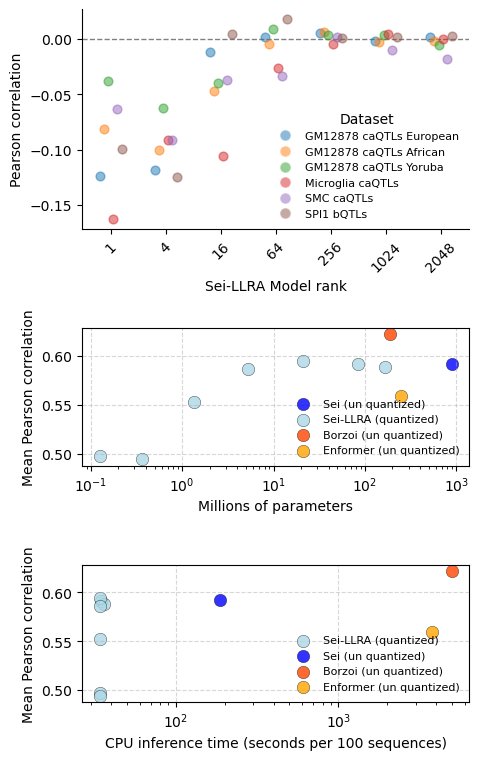

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

# --- Read runtime data (same as previous scripts) ---
runtime_files = {
    "Sei-LLRA": "sei_count_times.csv",
    "Borzoi-LLRA": "borzoi_count_times.csv",
    "Enformer-LLRA": "enformer_count_times.csv"
}

# Read runtimes and compute mean across all runs for each model/rank
runtime_lookup = {}

for model_source, path in runtime_files.items():
    try:
        df_runtimes = pd.read_csv(path, sep=",", header=None)
        df_runtimes.columns = ['model', 'rank', 'iteration', 'forward_time_ms', 
                                'other_cpu_avg_usage', 'other_cpu_max_usage', 'contaminated']
        
        print(f"\n{model_source} - Loaded {len(df_runtimes)} rows")
        
    except Exception as e:
        print(f"Warning: couldn't read runtime file {path}: {e}")
        continue

    # Filter out contaminated runs
    df_runtimes = df_runtimes[df_runtimes['contaminated'] == False]
    print(f"After filtering contaminated: {len(df_runtimes)} rows")

    if model_source == "Sei-LLRA":
        # Group by rank and take mean of forward_time_ms across all iterations
        grouped = df_runtimes.groupby('rank')['forward_time_ms'].mean()
        
        for rank, time_ms in grouped.items():
            # Convert ms per 1 sequence to seconds per 100 sequences
            time_seconds_per_100 = (time_ms / 1000) * 100
            if rank == "full":
                runtime_lookup["sei"] = float(time_seconds_per_100)
            else:
                key = f"seilora_{rank}"
                runtime_lookup[key] = float(time_seconds_per_100)
    
    elif model_source == "Borzoi-LLRA":
        # Group by model and rank, take mean of forward_time_ms
        grouped = df_runtimes.groupby(['model', 'rank'])['forward_time_ms'].mean()
        
        for (model, rank), time_ms in grouped.items():
            # Convert ms per 1 sequence to seconds per 100 sequences
            time_seconds_per_100 = (time_ms / 1000) * 100
            if rank == "full":
                runtime_lookup["borzoi"] = float(time_seconds_per_100)
            else:
                key = f"{model}_lora_{rank}"
                runtime_lookup[key] = float(time_seconds_per_100)
    
    elif model_source == "Enformer-LLRA":
        # Group by model and rank, take mean of forward_time_ms
        grouped = df_runtimes.groupby(['model', 'rank'])['forward_time_ms'].mean()
        
        for (model, rank), time_ms in grouped.items():
            # Convert ms per 1 sequence to seconds per 100 sequences
            time_seconds_per_100 = (time_ms / 1000) * 100
            if rank == "full":
                runtime_lookup["enformer"] = float(time_seconds_per_100)
            else:
                key = f"{model}_lora_{rank}"
                runtime_lookup[key] = float(time_seconds_per_100)

print("\nRuntime lookup:")
for key, val in runtime_lookup.items():
    print(f"{key}: {val:.2f} sec/100seq")

# --- Replace mean_time_by_model with runtime_lookup ---
mean_time_by_model = runtime_lookup

# --- assume these are defined from A ---
# pearson_diffs: dict of dicts for Δ Pearson per rank per dataset
# mean_pearson: dict of mean Pearson per model
# model_sizes: dict of model sizes
# benchmarks: list of dataset names
# ranks: list of SeiLora ranks

# define dataset colors for consistent coloring (like B)
dataset_colors = {ds: plt.cm.tab10(i) for i, ds in enumerate(benchmarks)}


# --- Figure ---
fig = plt.figure(figsize=(5, 4 + 2.5 + 2.5))  # total height = 4 + 2.5 + 2.5 = 9
gs = GridSpec(3, 1, figure=fig, height_ratios=[4, 2.5, 2.5], hspace=0.6)

# --- create axes ---
ax_c1 = fig.add_subplot(gs[0, 0])  # first subplot (Δ Pearson) -> 6x4
ax_c2 = fig.add_subplot(gs[1, 0])  # second subplot -> 6x2.5
ax_c3 = fig.add_subplot(gs[2, 0])  # third subplot -> 6x2.5

# Deterministic jitter offsets
_dataset_base_offsets = np.linspace(-(len(dataset_labels) - 1)/2.0,
                                    (len(dataset_labels) - 1)/2.0, len(dataset_labels)) * 0.08
dataset_offsets = {ds: float(off) for ds, off in zip(dataset_labels.keys(), _dataset_base_offsets)}

def jitter_positions(n_points, rank_idx):
    """Deterministic x-offsets for scatter points."""
    offs = _dataset_base_offsets[:n_points]
    return np.array([rank_idx + o for o in offs])



# -----------------------------
# 1. Δ Pearson scatter per dataset
# -----------------------------

ax_c1.axhline(0, color="grey", linestyle="--", linewidth=1)
# ax_c1.set_title("Δ Pearson correlation per SeiLora rank", fontsize=12)

# store scatter handles for legend
scatter_handles = []

for i, rank in enumerate(ranks):
    y = []
    colors = []
    datasets_present = []
    for ds in benchmarks:
        val = pearson_diffs.get(f"seilora_{rank}", {}).get(ds, np.nan)
        if not np.isnan(val):
            y.append(val)
            colors.append(dataset_colors[ds])
            datasets_present.append(ds)
    if y:
        x = jitter_positions(len(y), i)
        for xi, yi, color, ds in zip(x, y, colors, datasets_present):
            scatter_handles.append(ax_c1.scatter(xi, yi, color=color, s=40, alpha=0.5, zorder=3))

ax_c1.set_xticks(np.arange(len(ranks)))
ax_c1.set_xticklabels(ranks, rotation=45)
ax_c1.set_xlabel("Sei-LLRA Model rank")
ax_c1.set_ylabel("Pearson correlation")
ax_c1.spines["top"].set_visible(False)
ax_c1.spines["right"].set_visible(False)

# Add legend for datasets
legend_handles = [Line2D([0], [0], marker='o', color='w', label=name,
                         markerfacecolor=color, markersize=8, alpha=0.5)
                  for ds, (name, color) in zip(dataset_labels.keys(),
                                               zip(dataset_labels.values(), dataset_colors.values()))]
ax_c1.legend(handles=legend_handles, title="Dataset", frameon=False, fontsize=8, loc='lower right')

# -----------------------------
# 2. Model size vs mean Pearson
# -----------------------------

seen_labels = set()
for model, pearson in mean_pearson.items():
    size = model_sizes.get(model)
    if size is None:
        continue

    if model.startswith("seilora"):
        color = "lightblue"
        label = "Sei-LLRA (quantized)"
    elif model == "sei":
        color = "blue"
        label = "Sei (un quantized)"
    elif model == "enformer":
        color = "orange"
        label = "Enformer (un quantized)"
    elif model == "borzoi":
        color = "orangered"
        label = "Borzoi (un quantized)"

    plot_label = label if label not in seen_labels else None
    seen_labels.add(label)

    ax_c2.scatter(size/1e6, pearson, color=color, s=80, alpha=0.8, label=plot_label, edgecolor='k', linewidth=0.3)

ax_c2.set_xlabel("Millions of parameters")
ax_c2.set_ylabel("Mean Pearson correlation")
ax_c2.set_xscale('log')
# ax_c2.set_title("Model size vs mean Pearson correlation", fontsize=12)
ax_c2.legend(frameon=False, fontsize=8, loc="lower right")
ax_c2.grid(True, linestyle="--", alpha=0.5)

# -----------------------------
# 3. CPU runtime vs mean Pearson
# -----------------------------

seen_labels = set()
for model, t in mean_time_by_model.items():
    size = model_sizes.get(model)
    pearson = mean_pearson.get(model)
    if t is None or np.isnan(t) or pearson is None or np.isnan(pearson):
        continue

    if model.startswith("seilora"):
        color = "lightblue"
        label = "Sei-LLRA (quantized)"
    elif model == "sei":
        color = "blue"
        label = "Sei (un quantized)"
    elif model == "enformer":
        color = "orange"
        label = "Enformer (un quantized)"
    elif model == "borzoi":
        color = "orangered"
        label = "Borzoi (un quantized)"

    plot_label = label if label not in seen_labels else None
    seen_labels.add(label)
    ax_c3.scatter(t, pearson, color=color, s=80, alpha=0.8, label=plot_label, edgecolor='k', linewidth=0.3)

ax_c3.set_xlabel("CPU inference time (seconds per 100 sequences)")
ax_c3.set_ylabel("Mean Pearson correlation")
ax_c3.set_xscale('log')
# ax_c3.set_title("Model speed vs mean Pearson correlation", fontsize=12)
ax_c3.legend(frameon=False, fontsize=8, loc="lower right")
ax_c3.grid(True, linestyle="--", alpha=0.5)

# plt.suptitle("Sei and SeiLora Performance Across caQTL Datasets", fontsize=14, weight="bold")
plt.tight_layout()
plt.savefig("../figs/fig3_reformatted_B_style_with_legend.png", dpi=300)
plt.show()

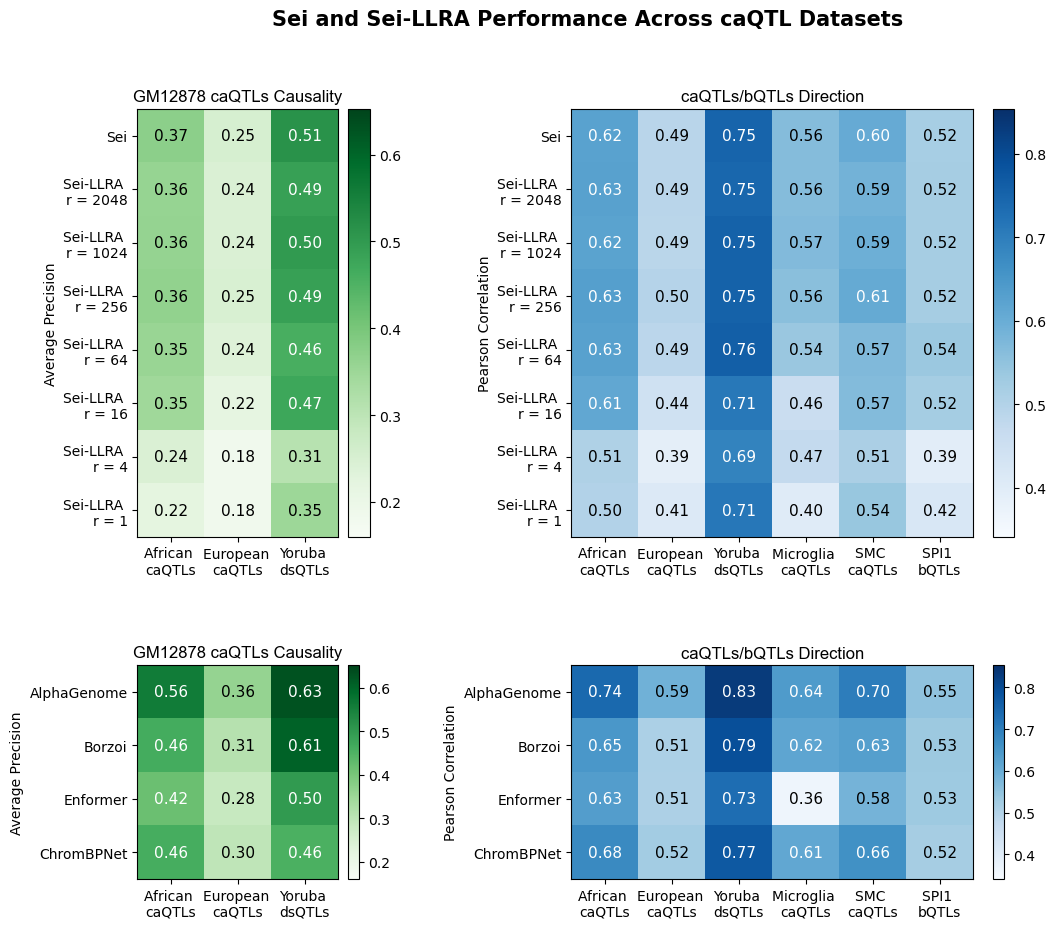

In [12]:
import numpy as np
import matplotlib.pyplot as plt
hfont = {"fontname": "Arial"}

# --- Custom display names for clarity ---
model_labels = {
    "sei": "Sei",
    "seilora_1": "Sei-LLRA \nr = 1",
    "seilora_4": "Sei-LLRA \nr = 4",
    "seilora_16": "Sei-LLRA \nr = 16",
    "seilora_64": "Sei-LLRA \nr = 64",
    "seilora_256": "Sei-LLRA \nr = 256",
    "seilora_1024": "Sei-LLRA \nr = 1024",
    "seilora_2048": "Sei-LLRA \nr = 2048",
    "alphagenome": "AlphaGenome", "borzoi": "Borzoi",
    "enformer": "Enformer", "chrombpnet" : "ChromBPNet"
}

dataset_labels = {
    "caqtls_eu_lcl": "European \ncaQTLs",
    "caqtls_afr_lcl": "African \ncaQTLs",
    "dsqtls_yoruba_lcl": "Yoruba \ndsQTLs",
    "caqtls_eu_microglia": "Microglia \ncaQTLs",
    "caqtls_eu_smc": "SMC \ncaQTLs",
    "bsqtls_eu_spi1": "SPI1 \nbQTLs",
}

model_order_a = ["sei", "seilora_2048", "seilora_1024", "seilora_256",
                 "seilora_64", "seilora_16", "seilora_4", "seilora_1"]
model_order_b = ["alphagenome", "borzoi", "enformer", "chrombpnet"]

caqtl_datasets_1 = ["caqtls_afr_lcl", "caqtls_eu_lcl", "dsqtls_yoruba_lcl"]
caqtl_datasets_2 = ["caqtls_eu_microglia", "caqtls_eu_smc", "bsqtls_eu_spi1"]

metric_labels = {"ap_signed": "Average Precision", "pearson_r": "Pearson Correlation"}

# --- Helper to build metric matrices ---
def make_matrix(metric, datasets, models_list):
    mat = []
    for model in models_list:
        row = [all_metrics.get(model, {}).get(ds, {}).get(metric, np.nan) for ds in datasets]
        mat.append(row)
    return np.array(mat, dtype=float)

# --- Heatmap ---
def plot_heatmap(ax, data, title, ylabel, xticks, yticks, cmap, vmin, vmax):
    im = ax.imshow(data, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(len(xticks)))
    ax.set_xticklabels([dataset_labels[d] for d in xticks], fontsize=10)
    ax.set_yticks(np.arange(len(yticks)))
    ax.set_yticklabels([model_labels[m] for m in yticks], fontsize=10)
    ax.set_title(title, fontsize=12, **hfont)
    ax.set_ylabel(metric_labels[ylabel])

    # annotate values
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            text = "–" if np.isnan(val) else f"{val:.2f}"
            color = "black" if np.isnan(val) or val < (vmin + vmax)/2 else "white"
            ax.text(j, i, text, ha="center", va="center", color=color, fontsize=11)
    return im

# --- Build matrices ---
mat_a1 = make_matrix("ap_signed", caqtl_datasets_1, model_order_a)
mat_a2 = make_matrix("pearson_r", caqtl_datasets_1 + caqtl_datasets_2, model_order_a)

mat_b1 = make_matrix("ap_signed", caqtl_datasets_1, model_order_b)
mat_b2 = make_matrix("pearson_r", caqtl_datasets_1 + caqtl_datasets_2, model_order_b)

def _global_vmin_vmax(arrs):
    vals = np.concatenate([a.flatten() for a in arrs])
    finite = vals[np.isfinite(vals)]
    lo, hi = np.min(finite), np.max(finite)
    pad = 0.05 * (hi - lo if hi != lo else abs(hi) + 1e-9)
    return lo - pad, hi + pad

vmin_ap, vmax_ap = _global_vmin_vmax([mat_a1, mat_b1])
vmin_pr, vmax_pr = _global_vmin_vmax([mat_a2, mat_b2])

# --- New layout: 2 rows × 2 columns ---
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(
    2, 2,
    width_ratios=[3, 6],   # <- A1 has 3 columns, A2 has 6
    height_ratios=[8, 4],
    hspace=0.4,
    wspace=0.5
)

axes = gs.subplots()

# --- Row A ---
im_a1 = plot_heatmap(
    axes[0,0], mat_a1,
    "GM12878 caQTLs Causality",
    "ap_signed", caqtl_datasets_1, model_order_a,
    cmap="Greens", vmin=vmin_ap, vmax=vmax_ap
)

im_a2 = plot_heatmap(
    axes[0,1], mat_a2,
    "caQTLs/bQTLs Direction",
    "pearson_r", caqtl_datasets_1 + caqtl_datasets_2, model_order_a,
    cmap="Blues", vmin=vmin_pr, vmax=vmax_pr
)



# --- Row B ---
im_b1 = plot_heatmap(
    axes[1,0], mat_b1,
    "GM12878 caQTLs Causality",
    "ap_signed", caqtl_datasets_1, model_order_b,
    cmap="Greens", vmin=vmin_ap, vmax=vmax_ap
)

im_b2 = plot_heatmap(
    axes[1,1], mat_b2,
    "caQTLs/bQTLs Direction",
    "pearson_r", caqtl_datasets_1 + caqtl_datasets_2, model_order_b,
    cmap="Blues", vmin=vmin_pr, vmax=vmax_pr
)

fig.colorbar(im_a1, ax=axes[0,0], pad=0.04, shrink=1.0)
fig.colorbar(im_a2, ax=axes[0,1], pad=0.04, shrink=1.0)

fig.colorbar(im_b1, ax=axes[1,0], pad=0.04, shrink=1.0)
fig.colorbar(im_b2, ax=axes[1,1], pad=0.04, shrink=1.0)

plt.suptitle("Sei and Sei-LLRA Performance Across caQTL Datasets", fontsize=15, weight="bold")
plt.savefig("../figs/fig3_combined.png", dpi=300, bbox_inches="tight")
plt.show()
